In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

C:\Users\FeiyuanYang\AppData\Local\Temp\ipykernel_14008\2345180160.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
folder = r'C:\Users\FeiyuanYang\OneDrive - Cambridge GaN Devices Ltd\Documents\CGD documents\Projects\T12009\dynamic'
file = 'T12009 SCW Rgon=Rgoff, PHM, RT Vgi and Ig data.csv'
path = os.path.join(folder, file)
df= pd.read_csv(path, comment="#")
print(df.columns)

Index(['chip_id', 'inductance', 'dc_voltage', 'peak_current',
       'inter_pulse_delay', 'pulse2_width', 'dead_time', 'gate_voltage',
       'gate_resistor', 'vdd', 'comment', 'drain_voltage', 'drain_current',
       'test_type', 'file', 'error', 'Vgi_measured (V)', 'Ig_measured (A)'],
      dtype='object')


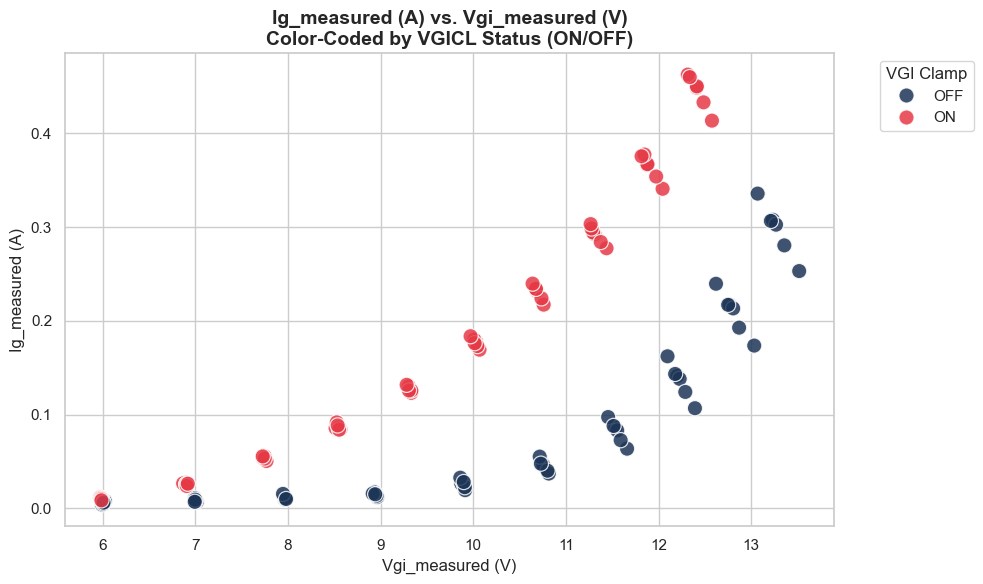

In [3]:
df["Condition"] = np.where(df["comment"].str.contains("VGICL=ON"), "ON", "OFF")

# 3. Create the plot layout
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Plot using hue for the two colors, and style for the distinct gate voltages
sns.scatterplot(
    data=df,
    x="Vgi_measured (V)",
    y="Ig_measured (A)",
    hue="Condition",
    palette={
        "ON": "#E63946",
        "OFF": "#1D3557",
    },  # Distinct Red (ON) and Dark Blue (OFF)
    #style="gate_voltage",  # Uses unique marker shapes for different voltages
    s=120,
    alpha=0.85,
)
# 6. Labels and legends formatting
plt.title(
    "Ig_measured (A) vs. Vgi_measured (V)\nColor-Coded by VGICL Status (ON/OFF)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Vgi_measured (V)", fontsize=12)
plt.ylabel("Ig_measured (A)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="VGI Clamp")
plt.tight_layout()

# 7. Display the final visualization
plt.show()

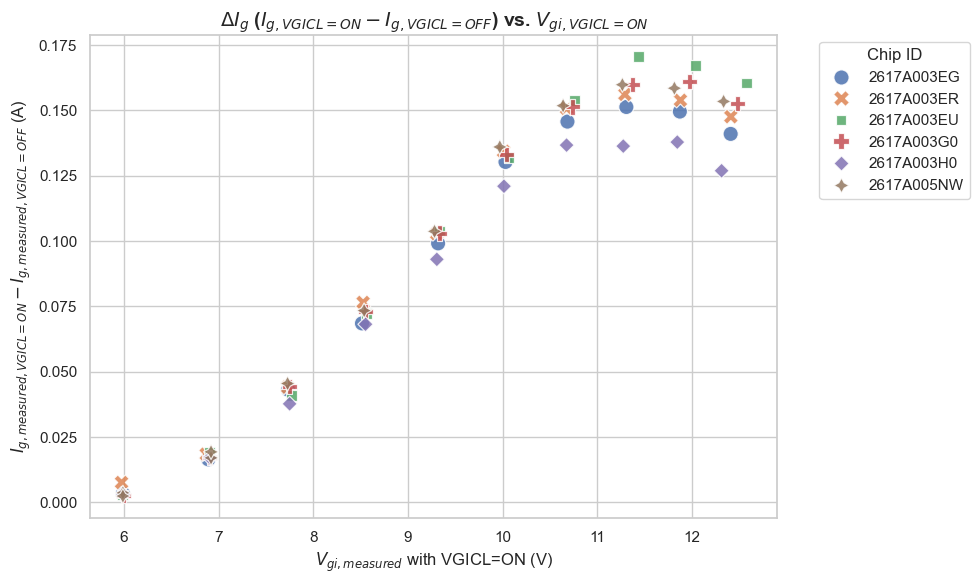

In [4]:
# 3. Separate and rename columns for merging
df_on = df[df["Condition"] == "ON"][
    ["chip_id", "gate_voltage", "Ig_measured (A)", "Vgi_measured (V)"]
].rename(columns={"Ig_measured (A)": "Ig_ON", "Vgi_measured (V)": "Vgi_ON"})

df_off = df[df["Condition"] == "OFF"][
    ["chip_id", "gate_voltage", "Ig_measured (A)", "Vgi_measured (V)"]
].rename(columns={"Ig_measured (A)": "Ig_OFF", "Vgi_measured (V)": "Vgi_OFF"})

# 4. Merge ON and OFF conditions on chip_id and gate_voltage
merged = pd.merge(df_on, df_off, on=["chip_id", "gate_voltage"], how="inner")

# 5. Calculate the current difference
merged["Delta_Ig"] = merged["Ig_ON"] - merged["Ig_OFF"]

# 6. Configure plot style using rcParams instead of .figure()
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

# 7. Generate the scatter plot, grouping by chip_id
ax = sns.scatterplot(
    data=merged,
    x="Vgi_ON",
    y="Delta_Ig",
    hue="chip_id",
    style="chip_id",
    s=120,
    alpha=0.85,
)

# 8. Titles and Labels
plt.title(
    r"$\Delta I_g$ ($I_{g,VGICL=ON} - I_{g,VGICL=OFF}$) vs. $V_{gi,VGICL=ON}$",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel(r"$V_{gi, measured}$ with VGICL=ON (V)", fontsize=12)
plt.ylabel(r"$I_{g, measured, VGICL=ON} - I_{g, measured, VGICL=OFF}$ (A)", fontsize=12)
plt.legend(title="Chip ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# 9. Save image file
plt.show()